# Cryptocurrency Momentum & Reversal Strategies (Revised v2)

**Wall Street Quants - Statistical Arbitrage in Cryptocurrencies**

## Revisions from v1 (addressing new feedback to improve alpha t-stat and Sharpe)

| # | Feedback | How Addressed |
|---|----------|---------------|
| 1 | At least 2 years for training AND test | Training: Apr 2022 - Apr 2024 (2 yrs). Test: Apr 2024 - Apr 2026 (2 yrs). |
| 2 | Expand universe from 10 coins to 20-30+ | 35-coin candidate list; filtered to those with full history (target 30+). |
| 3 | Move from daily to 4h bars | `KLINE_INTERVAL_4HOUR`. Annualization uses `sqrt(2190)` (365 days x 6 bars/day). |
| (kept) | Transaction costs 20 bps | Unchanged, still 20 bps. Rebalancing frequency control now scales in 4h bars. |
| (kept) | Train/test split | Parameters selected on training period only; test held out. |
| (kept) | Rolling quarterly combination weights | Quarter-by-quarter weight estimation, OOS application. |
| (kept) | Alpha t-statistic | OLS regression of strategy returns on BTC benchmark. |

**Goal:** Higher alpha t-stat and Sharpe ratio from more data, more diversification,
and finer sampling granularity.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime, timezone
from binance.client import Client as bnb_client
from IPython.display import display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# === KEY CONSTANTS ===
BARS_PER_DAY = 6                 # 4h bars -> 24h / 4h = 6
BARS_PER_YEAR = 365 * BARS_PER_DAY   # 2190 bars per year
EXEC_COST_BPS = 20               # 20 bps execution cost per unit turnover
TRAIN_END = pd.Timestamp('2024-04-01', tz='UTC')  # 2 yr train / 2 yr test
DATA_START = '2022-04-01'
DATA_END = '2026-04-02'

print('All imports successful.')
print(f'Frequency: 4-hour bars ({BARS_PER_DAY} bars/day, {BARS_PER_YEAR} bars/year)')
print(f'Transaction cost: {EXEC_COST_BPS} bps')
print(f'Data range: {DATA_START} to {DATA_END}')
print(f'Training period ends: {TRAIN_END.date()}')

All imports successful.
Frequency: 4-hour bars (6 bars/day, 2190 bars/year)
Transaction cost: 20 bps
Data range: 2022-04-01 to 2026-04-02
Training period ends: 2024-04-01


---
## Section 1: Data Collection

Fetch 4-hour close prices from Binance for an expanded universe of 35 large-cap crypto pairs.
We attempt to fetch all 35 tickers; those without complete history across the full window
(Apr 2022 - Apr 2026) are dropped. Our goal is a final universe of at least 30 coins.

Moving from daily to 4h bars gives ~6x the data density, reducing idiosyncratic noise
and improving the statistical power of our t-stat tests.

In [2]:
client = bnb_client(tld='US')

def get_binance_px(symbol, freq, start_ts=DATA_START, end_ts=DATA_END):
    data = client.get_historical_klines(symbol, freq, start_ts, end_ts)
    columns = [
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_volume', 'num_trades',
        'taker_base_volume', 'taker_quote_volume', 'ignore'
    ]
    data = pd.DataFrame(data, columns=columns)
    data['open_time'] = data['open_time'].map(
        lambda x: datetime.fromtimestamp(x / 1000, tz=timezone.utc)
    )
    for col in ['open', 'high', 'low', 'close', 'volume', 'quote_volume']:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    data.set_index('open_time', inplace=True)
    return data

# Expanded candidate universe: 35 large-cap cryptos that were listed on Binance before Apr 2022
candidate_tickers = [
    'BTCUSDT',  'ETHUSDT',  'BNBUSDT',  'XRPUSDT',  'ADAUSDT',
    'SOLUSDT',  'DOTUSDT',  'AVAXUSDT', 'LINKUSDT', 'MATICUSDT',
    'LTCUSDT',  'TRXUSDT',  'ATOMUSDT', 'UNIUSDT',  'NEARUSDT',
    'ETCUSDT',  'FILUSDT',  'AAVEUSDT', 'ALGOUSDT', 'SANDUSDT',
    'MANAUSDT', 'AXSUSDT',  'ICPUSDT',  'XLMUSDT',  'VETUSDT',
    'HBARUSDT', 'APEUSDT',  'XTZUSDT',  'CRVUSDT',  'BATUSDT',
    'COMPUSDT', 'ZECUSDT',  'ENJUSDT',  'CHZUSDT',  'GRTUSDT',
]

# MATIC was renamed POL in Sept 2024 - handle both tickers seamlessly
# POLUSDT is a fallback for MATIC's later period
matic_alts = {'MATICUSDT': 'POLUSDT'}

price_dict = {}
return_dict = {}
fetch_summary = []

for ticker in candidate_tickers:
    try:
        df = get_binance_px(ticker, bnb_client.KLINE_INTERVAL_4HOUR)
        if len(df) == 0 and ticker in matic_alts:
            df = get_binance_px(matic_alts[ticker], bnb_client.KLINE_INTERVAL_4HOUR)
            if len(df) > 0:
                ticker = matic_alts[ticker]
        price_dict[ticker] = df['close']
        return_dict[ticker] = df['close'].pct_change()
        fetch_summary.append((ticker, len(df),
                              df.index[0] if len(df) > 0 else None,
                              df.index[-1] if len(df) > 0 else None))
        print(f'  {ticker}: {len(df)} bars')
    except Exception as e:
        if ticker in matic_alts:
            try:
                alt = matic_alts[ticker]
                df = get_binance_px(alt, bnb_client.KLINE_INTERVAL_4HOUR)
                price_dict[alt] = df['close']
                return_dict[alt] = df['close'].pct_change()
                fetch_summary.append((alt, len(df),
                                      df.index[0] if len(df) > 0 else None,
                                      df.index[-1] if len(df) > 0 else None))
                print(f'  {alt} (alt for {ticker}): {len(df)} bars')
            except Exception as e2:
                print(f'  {ticker}/{alt} FAILED: {e2}')
        else:
            print(f'  {ticker} FAILED: {e}')

# Build full price / return matrices
prices_all = pd.DataFrame(price_dict).sort_index()
returns_all = pd.DataFrame(return_dict).sort_index()

print()
print(f'Raw price matrix: {prices_all.shape}')
print(f'Date range: {prices_all.index[0]} to {prices_all.index[-1]}')

  BTCUSDT: 8772 bars
  ETHUSDT: 8772 bars
  BNBUSDT: 8772 bars
  XRPUSDT: 5956 bars
  ADAUSDT: 8772 bars
  SOLUSDT: 8772 bars
  DOTUSDT: 8772 bars
  AVAXUSDT: 8772 bars
  LINKUSDT: 8772 bars
  MATICUSDT: 6090 bars
  LTCUSDT: 8772 bars
  TRXUSDT: 2298 bars
  ATOMUSDT: 8772 bars
  UNIUSDT: 8772 bars
  NEARUSDT: 8772 bars
  ETCUSDT: 8772 bars
  FILUSDT: 8772 bars
  AAVEUSDT: 8772 bars
  ALGOUSDT: 8772 bars
  SANDUSDT: 7647 bars
  MANAUSDT: 8772 bars
  AXSUSDT: 8772 bars
  ICPUSDT: 8283 bars
  XLMUSDT: 8772 bars
  VETUSDT: 8772 bars
  HBARUSDT: 6061 bars
  APEUSDT: 8772 bars
  XTZUSDT: 6061 bars
  CRVUSDT: 8772 bars
  BATUSDT: 8772 bars
  COMPUSDT: 8772 bars
  ZECUSDT: 8772 bars
  ENJUSDT: 8772 bars
  CHZUSDT: 8772 bars
  GRTUSDT: 8772 bars

Raw price matrix: (8772, 35)
Date range: 2022-04-01 00:00:00+00:00 to 2026-04-02 00:00:00+00:00


In [3]:
# Filter universe to tickers with complete history across the full window
# A ticker must have non-null prices for at least 95% of the target date range
target_start = pd.Timestamp(DATA_START, tz='UTC')
target_end = pd.Timestamp(DATA_END, tz='UTC')

# The universe master index is BTC's (it has full history guaranteed)
if 'BTCUSDT' in prices_all.columns:
    master_idx = prices_all['BTCUSDT'].dropna().index
else:
    master_idx = prices_all.index

full_length = len(master_idx)
min_required = int(full_length * 0.95)

kept, dropped = [], []
for col in prices_all.columns:
    s = prices_all[col].dropna()
    if len(s) >= min_required and s.index.min() <= target_start + pd.Timedelta(days=2):
        kept.append(col)
    else:
        dropped.append((col, len(s)))

prices = prices_all[kept].reindex(master_idx).dropna(how='all')
returns = prices.pct_change().dropna(how='all')

print(f'Universe after filtering: {len(kept)} / {len(prices_all.columns)} tickers kept')
print(f'Kept: {kept}')
if dropped:
    print(f'Dropped (insufficient history): {[(d[0], f"{d[1]} bars") for d in dropped]}')
print()
print(f'Final price matrix: {prices.shape}')
print(f'Final return matrix: {returns.shape}')
print(f'Index range: {prices.index[0]} to {prices.index[-1]}')

Universe after filtering: 28 / 35 tickers kept
Kept: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'SOLUSDT', 'DOTUSDT', 'AVAXUSDT', 'LINKUSDT', 'LTCUSDT', 'ATOMUSDT', 'UNIUSDT', 'NEARUSDT', 'ETCUSDT', 'FILUSDT', 'AAVEUSDT', 'ALGOUSDT', 'MANAUSDT', 'AXSUSDT', 'XLMUSDT', 'VETUSDT', 'APEUSDT', 'CRVUSDT', 'BATUSDT', 'COMPUSDT', 'ZECUSDT', 'ENJUSDT', 'CHZUSDT', 'GRTUSDT']
Dropped (insufficient history): [('XRPUSDT', '5956 bars'), ('MATICUSDT', '6090 bars'), ('TRXUSDT', '2298 bars'), ('SANDUSDT', '7647 bars'), ('ICPUSDT', '8283 bars'), ('HBARUSDT', '6061 bars'), ('XTZUSDT', '6061 bars')]

Final price matrix: (8772, 28)
Final return matrix: (8771, 28)
Index range: 2022-04-01 00:00:00+00:00 to 2026-04-02 00:00:00+00:00


---
## Section 2: Train / Test Split

- **Training period** (Apr 2022 - Apr 2024, 2 years): used for all parameter selection
- **Test period** (Apr 2024 - Apr 2026, 2 years): held out for out-of-sample evaluation

All strategy parameters (lookback, rebalancing frequency, skip) are chosen to maximize
**net Sharpe ratio** (after 20 bps costs) on the training set only. The test set is
never used during parameter selection.

Each period spans ~4380 4h bars (~2 years x 2190 bars/yr), giving much more statistical
power than the ~365 daily bars in v1.

In [4]:
train_returns = returns[returns.index < TRAIN_END]
test_returns = returns[returns.index >= TRAIN_END]
train_prices = prices[prices.index < TRAIN_END]
test_prices = prices[prices.index >= TRAIN_END]

print(f'Training: {train_returns.index[0]} to {train_returns.index[-1]} ({len(train_returns)} bars)')
print(f'Test:     {test_returns.index[0]} to {test_returns.index[-1]} ({len(test_returns)} bars)')

# Summary statistics for both periods
def summary_stats(ret_df, ann=BARS_PER_YEAR):
    stats = {}
    for c in ret_df.columns:
        r = ret_df[c].dropna()
        stats[c] = {
            'Ann. Return (%)': r.mean() * ann * 100,
            'Ann. Vol (%)': r.std() * np.sqrt(ann) * 100,
            'Sharpe': (r.mean() / r.std()) * np.sqrt(ann) if r.std() > 0 else 0,
        }
    return pd.DataFrame(stats).T.round(3)

print()
print('=== Training Period Asset Statistics ===')
display(summary_stats(train_returns))
print()
print('=== Test Period Asset Statistics ===')
display(summary_stats(test_returns))

Training: 2022-04-01 04:00:00+00:00 to 2024-03-31 20:00:00+00:00 (4384 bars)
Test:     2024-04-01 00:00:00+00:00 to 2026-04-02 00:00:00+00:00 (4387 bars)

=== Training Period Asset Statistics ===


,Ann. Return (%),Ann. Vol (%),Sharpe
BTCUSDT,36.529,51.120,0.715
ETHUSDT,26.829,64.836,0.414
BNBUSDT,36.867,60.516,0.609
ADAUSDT,4.130,79.637,0.052
SOLUSDT,82.160,106.883,0.769
DOTUSDT,-7.647,78.944,-0.097
AVAXUSDT,21.803,98.550,0.221
LINKUSDT,44.392,85.740,0.518
LTCUSDT,22.001,76.229,0.289
ATOMUSDT,-4.057,86.033,-0.047



=== Test Period Asset Statistics ===


,Ann. Return (%),Ann. Vol (%),Sharpe
BTCUSDT,7.634,47.026,0.162
ETHUSDT,-5.033,68.593,-0.073
BNBUSDT,13.723,54.379,0.252
ADAUSDT,-6.133,93.671,-0.065
SOLUSDT,-13.663,81.674,-0.167
DOTUSDT,-61.988,90.296,-0.686
AVAXUSDT,-48.223,91.938,-0.525
LINKUSDT,0.998,90.611,0.011
LTCUSDT,-1.358,81.235,-0.017
ATOMUSDT,-57.189,92.872,-0.616


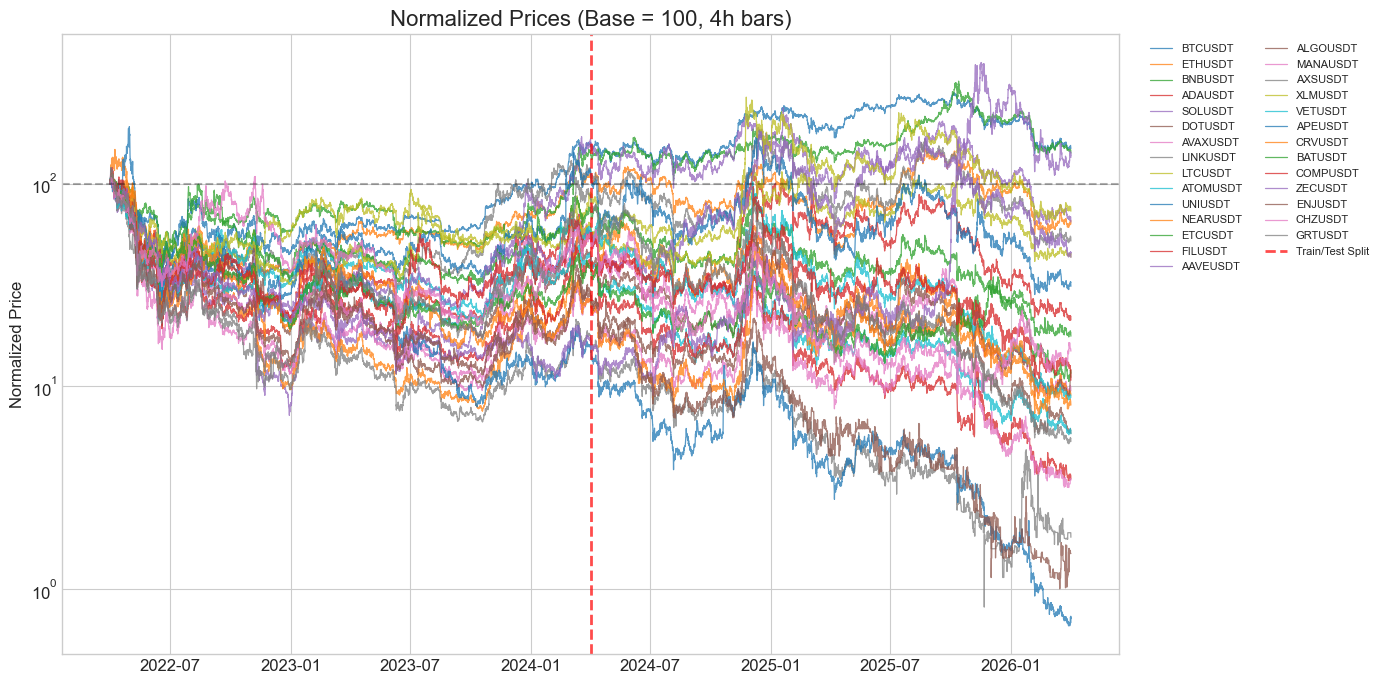

In [5]:
# Normalized price paths (base 100) with train/test boundary
first_valid = prices.dropna(how='all').iloc[0]
normalized = prices.divide(first_valid) * 100

fig, ax = plt.subplots(figsize=(14, 7))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=0.9, alpha=0.75)
ax.axvline(TRAIN_END, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Train/Test Split')
ax.set_title('Normalized Prices (Base = 100, 4h bars)', fontsize=16)
ax.set_ylabel('Normalized Price')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)
ax.axhline(100, color='black', linestyle='--', alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

---
## Section 3: Strategy Functions

Both strategies use **bar-based** parameters now that we're on 4h frequency.

- `lookback` / `window`: number of 4h bars (e.g. 180 bars = 30 days)
- `rebal_freq`: rebalance every N bars (e.g. 42 bars = 1 week)
- `skip`: skip most recent N bars (e.g. 6 bars = 1 day gap)

Annualization uses `sqrt(2190)` = `sqrt(365 * 6)` for 4h data.

Lower-frequency rebalancing (weekly / bi-weekly in bar counts) is essential at
20 bps costs: rebalancing every bar would cost ~300% annualized.

In [6]:
def max_drawdown(ret):
    cum = (1 + ret).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()


def compute_momentum_strategy(returns_df, lookback, rebal_freq=1, skip=0):
    '''Cross-sectional momentum with turnover control.

    Parameters
    ----------
    returns_df : DataFrame of per-bar returns
    lookback : int, trailing return window (bars)
    rebal_freq : int, rebalance every N bars (1 = every bar)
    skip : int, skip most recent N bars (momentum gap)

    Returns
    -------
    strat_ret : Series of per-bar strategy returns
    actual_w : DataFrame of portfolio weights
    '''
    if skip > 0:
        trailing = returns_df.shift(skip).rolling(lookback).sum()
    else:
        trailing = returns_df.rolling(lookback).sum()

    ranks = trailing.rank(axis=1)
    target_w = ranks.subtract(ranks.mean(axis=1), axis=0)
    target_w = target_w.divide(target_w.abs().sum(axis=1), axis=0)
    target_w = target_w.shift(1)  # avoid lookahead

    if rebal_freq > 1:
        valid = target_w.dropna(how='any').index
        rebal_dates = valid[::rebal_freq]
        actual_w = target_w.loc[rebal_dates].reindex(target_w.index, method='ffill')
    else:
        actual_w = target_w

    strat_ret = (actual_w * returns_df).sum(axis=1)
    return strat_ret, actual_w


def compute_reversal_strategy(returns_df, window, rebal_freq=1):
    '''Cross-sectional mean-reversion with turnover control.

    Parameters
    ----------
    returns_df : DataFrame of per-bar returns
    window : int, z-score lookback window (bars)
    rebal_freq : int, rebalance every N bars (1 = every bar)

    Returns
    -------
    strat_ret : Series of per-bar strategy returns
    actual_w : DataFrame of portfolio weights
    '''
    rmean = returns_df.rolling(window).mean()
    rstd = returns_df.rolling(window).std()
    zscore = (returns_df - rmean) / rstd

    ranks = (-zscore).rank(axis=1)  # long oversold, short overbought
    target_w = ranks.subtract(ranks.mean(axis=1), axis=0)
    target_w = target_w.divide(target_w.abs().sum(axis=1), axis=0)
    target_w = target_w.shift(1)

    if rebal_freq > 1:
        valid = target_w.dropna(how='any').index
        rebal_dates = valid[::rebal_freq]
        actual_w = target_w.loc[rebal_dates].reindex(target_w.index, method='ffill')
    else:
        actual_w = target_w

    strat_ret = (actual_w * returns_df).sum(axis=1)
    return strat_ret, actual_w


def compute_turnover(weights_df):
    '''Per-bar turnover = sum of absolute weight changes.'''
    return weights_df.diff().abs().sum(axis=1)


def compute_alpha_tstat(strat_ret, bench_ret, ann=BARS_PER_YEAR):
    '''OLS: r_strat = alpha + beta * r_bench + epsilon.
    Returns (annualized alpha, alpha t-stat, beta, R-squared).'''
    common = strat_ret.dropna().index.intersection(bench_ret.dropna().index)
    if len(common) < 30:
        return 0, 0, 0, 0
    y = strat_ret.loc[common].values
    X = sm.add_constant(bench_ret.loc[common].values)
    model = sm.OLS(y, X).fit()
    return model.params[0] * ann, model.tvalues[0], model.params[1], model.rsquared


def perf_metrics(ret):
    '''Compute standard performance metrics.'''
    ann_ret = ret.mean() * BARS_PER_YEAR
    ann_vol = ret.std() * np.sqrt(BARS_PER_YEAR)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    mdd = max_drawdown(ret)
    return {
        'Ann. Return (%)': ann_ret * 100,
        'Ann. Vol (%)': ann_vol * 100,
        'Sharpe': sharpe,
        'Max DD (%)': mdd * 100,
    }

print('Strategy functions defined.')

Strategy functions defined.


---
## Section 4: Parameter Selection (Training Set Only)

Grid search over strategy parameters, evaluating the **net Sharpe ratio** (after 20 bps
costs) on the training set.

All counts below are in **4h bars**. Reference: 6 bars = 1 day, 42 bars = 1 week.

**Momentum search grid:**
- Lookback: [60, 90, 120, 180, 270, 360, 540] bars (= 10, 15, 20, 30, 45, 60, 90 days)
- Rebalancing: [6, 18, 42, 84, 126, 168] bars (= daily, 3d, weekly, 2wk, 3wk, 4wk)
- Skip: [0, 6, 18] bars (= 0, 1 day, 3 days gap)

**Reversal search grid:**
- Window: [30, 60, 90, 120, 180, 270, 360] bars (= 5, 10, 15, 20, 30, 45, 60 days)
- Rebalancing: [6, 18, 42, 84, 126, 168] bars

In [7]:
print('=== Momentum Parameter Search (Training Set) ===')
print(f'Evaluating net Sharpe at {EXEC_COST_BPS} bps cost')
print()

mom_lookbacks = [60, 90, 120, 180, 270, 360, 540]
mom_rebal_freqs = [6, 18, 42, 84, 126, 168]
mom_skips = [0, 6, 18]

mom_results = []
for lb in mom_lookbacks:
    for rf in mom_rebal_freqs:
        for sk in mom_skips:
            ret, wts = compute_momentum_strategy(train_returns, lb, rf, sk)
            ret_clean = ret.dropna()
            if len(ret_clean) < 500:
                continue
            to = compute_turnover(wts).reindex(ret_clean.index, fill_value=0)
            net = ret_clean - to * (EXEC_COST_BPS / 10000)
            gross_sh = (ret_clean.mean() / ret_clean.std()) * np.sqrt(BARS_PER_YEAR) if ret_clean.std() > 0 else 0
            net_sh = (net.mean() / net.std()) * np.sqrt(BARS_PER_YEAR) if net.std() > 0 else 0
            mom_results.append({
                'lookback': lb, 'rebal_freq': rf, 'skip': sk,
                'gross_sharpe': round(gross_sh, 3),
                'net_sharpe': round(net_sh, 3),
                'avg_turnover': round(to.mean(), 5),
                'ann_cost_pct': round(to.mean() * EXEC_COST_BPS / 10000 * BARS_PER_YEAR * 100, 2)
            })

mom_df = pd.DataFrame(mom_results).sort_values('net_sharpe', ascending=False)
print(f'Total combinations evaluated: {len(mom_df)}')
print('Top 15 parameter combinations (ranked by net Sharpe):')
display(mom_df.head(15))

best_mom = mom_df.iloc[0]
best_mom_params = {
    'lookback': int(best_mom['lookback']),
    'rebal_freq': int(best_mom['rebal_freq']),
    'skip': int(best_mom['skip'])
}
print()
print(f'SELECTED: lookback={best_mom_params["lookback"]} bars ({best_mom_params["lookback"]/BARS_PER_DAY:.1f} days), '
      f'rebal_freq={best_mom_params["rebal_freq"]} bars ({best_mom_params["rebal_freq"]/BARS_PER_DAY:.1f} days), '
      f'skip={best_mom_params["skip"]} bars ({best_mom_params["skip"]/BARS_PER_DAY:.1f} days)')
print(f'Training Net Sharpe: {best_mom["net_sharpe"]:.3f}')
print(f'Avg per-bar Turnover: {best_mom["avg_turnover"]:.5f}')
print(f'Annualized Cost Drag: {best_mom["ann_cost_pct"]:.2f}%')

=== Momentum Parameter Search (Training Set) ===
Evaluating net Sharpe at 20 bps cost

Total combinations evaluated: 126
Top 15 parameter combinations (ranked by net Sharpe):


,lookback,rebal_freq,skip,gross_sharpe,net_sharpe,avg_turnover,ann_cost_pct
34,90,168,6,0.984,0.779,0.00756,3.31
28,90,84,6,1.119,0.740,0.01453,6.36
27,90,84,0,1.065,0.691,0.01453,6.36
121,540,126,6,0.747,0.628,0.00422,1.85
122,540,126,18,0.701,0.581,0.00422,1.85
13,60,126,6,0.838,0.561,0.01007,4.41
120,540,126,0,0.660,0.540,0.00422,1.85
29,90,84,18,0.886,0.514,0.01420,6.22
33,90,168,0,0.693,0.490,0.00756,3.31
25,90,42,6,1.007,0.483,0.02088,9.15



SELECTED: lookback=90 bars (15.0 days), rebal_freq=168 bars (28.0 days), skip=6 bars (1.0 days)
Training Net Sharpe: 0.779
Avg per-bar Turnover: 0.00756
Annualized Cost Drag: 3.31%


In [8]:
print('=== Reversal Parameter Search (Training Set) ===')
print(f'Evaluating net Sharpe at {EXEC_COST_BPS} bps cost')
print()

rev_windows = [30, 60, 90, 120, 180, 270, 360]
rev_rebal_freqs = [6, 18, 42, 84, 126, 168]

rev_results = []
for w in rev_windows:
    for rf in rev_rebal_freqs:
        ret, wts = compute_reversal_strategy(train_returns, w, rf)
        ret_clean = ret.dropna()
        if len(ret_clean) < 500:
            continue
        to = compute_turnover(wts).reindex(ret_clean.index, fill_value=0)
        net = ret_clean - to * (EXEC_COST_BPS / 10000)
        gross_sh = (ret_clean.mean() / ret_clean.std()) * np.sqrt(BARS_PER_YEAR) if ret_clean.std() > 0 else 0
        net_sh = (net.mean() / net.std()) * np.sqrt(BARS_PER_YEAR) if net.std() > 0 else 0
        rev_results.append({
            'window': w, 'rebal_freq': rf,
            'gross_sharpe': round(gross_sh, 3),
            'net_sharpe': round(net_sh, 3),
            'avg_turnover': round(to.mean(), 5),
            'ann_cost_pct': round(to.mean() * EXEC_COST_BPS / 10000 * BARS_PER_YEAR * 100, 2)
        })

rev_df = pd.DataFrame(rev_results).sort_values('net_sharpe', ascending=False)
print(f'Total combinations evaluated: {len(rev_df)}')
print('Top 15 parameter combinations (ranked by net Sharpe):')
display(rev_df.head(15))

best_rev = rev_df.iloc[0]
best_rev_params = {
    'window': int(best_rev['window']),
    'rebal_freq': int(best_rev['rebal_freq'])
}
print()
print(f'SELECTED: window={best_rev_params["window"]} bars ({best_rev_params["window"]/BARS_PER_DAY:.1f} days), '
      f'rebal_freq={best_rev_params["rebal_freq"]} bars ({best_rev_params["rebal_freq"]/BARS_PER_DAY:.1f} days)')
print(f'Training Net Sharpe: {best_rev["net_sharpe"]:.3f}')
print(f'Avg per-bar Turnover: {best_rev["avg_turnover"]:.5f}')
print(f'Annualized Cost Drag: {best_rev["ann_cost_pct"]:.2f}%')

=== Reversal Parameter Search (Training Set) ===
Evaluating net Sharpe at 20 bps cost

Total combinations evaluated: 42
Top 15 parameter combinations (ranked by net Sharpe):


,window,rebal_freq,gross_sharpe,net_sharpe,avg_turnover,ann_cost_pct
10,60,126,1.725,1.431,0.01045,4.58
34,270,126,1.517,1.227,0.00978,4.28
9,60,84,1.315,0.887,0.01531,6.71
35,270,168,0.967,0.748,0.00741,3.24
4,30,126,0.977,0.697,0.01010,4.42
11,60,168,0.696,0.480,0.00765,3.35
16,90,126,0.669,0.381,0.01049,4.59
27,180,84,0.766,0.349,0.01485,6.50
33,270,84,0.641,0.226,0.01441,6.31
8,60,42,1.020,0.192,0.03082,13.50



SELECTED: window=60 bars (10.0 days), rebal_freq=126 bars (21.0 days)
Training Net Sharpe: 1.431
Avg per-bar Turnover: 0.01045
Annualized Cost Drag: 4.58%


---
## Section 5: Individual Strategy Evaluation (Train vs Test)

Run each strategy on the **full dataset** with the parameters selected above, then split
results into training and test periods. Running on the full dataset ensures that the
lookback window at the start of the test period is correctly populated with training data
(no warm-up gap).

In [9]:
# Run strategies on FULL dataset with selected parameters
mom_lb = best_mom_params['lookback']
mom_rf = best_mom_params['rebal_freq']
mom_sk = best_mom_params['skip']
rev_w = best_rev_params['window']
rev_rf = best_rev_params['rebal_freq']

print(f'Momentum params: lookback={mom_lb}, rebal_freq={mom_rf}, skip={mom_sk} (bars)')
print(f'Reversal params: window={rev_w}, rebal_freq={rev_rf} (bars)')

mom_ret_full, mom_wts_full = compute_momentum_strategy(returns, mom_lb, mom_rf, mom_sk)
rev_ret_full, rev_wts_full = compute_reversal_strategy(returns, rev_w, rev_rf)

# Compute turnover on full dataset
mom_to_full = compute_turnover(mom_wts_full)
rev_to_full = compute_turnover(rev_wts_full)

# Split into train / test
mom_ret_train = mom_ret_full[mom_ret_full.index < TRAIN_END].dropna()
mom_ret_test = mom_ret_full[mom_ret_full.index >= TRAIN_END].dropna()
rev_ret_train = rev_ret_full[rev_ret_full.index < TRAIN_END].dropna()
rev_ret_test = rev_ret_full[rev_ret_full.index >= TRAIN_END].dropna()

mom_to_train = mom_to_full.reindex(mom_ret_train.index, fill_value=0)
mom_to_test = mom_to_full.reindex(mom_ret_test.index, fill_value=0)
rev_to_train = rev_to_full.reindex(rev_ret_train.index, fill_value=0)
rev_to_test = rev_to_full.reindex(rev_ret_test.index, fill_value=0)

# Net returns (after 20 bps costs)
cost = EXEC_COST_BPS / 10000
mom_net_train = mom_ret_train - mom_to_train * cost
mom_net_test = mom_ret_test - mom_to_test * cost
rev_net_train = rev_ret_train - rev_to_train * cost
rev_net_test = rev_ret_test - rev_to_test * cost

print()
print(f'Momentum - Train: {len(mom_ret_train)} bars, Test: {len(mom_ret_test)} bars')
print(f'Reversal - Train: {len(rev_ret_train)} bars, Test: {len(rev_ret_test)} bars')

Momentum params: lookback=90, rebal_freq=168, skip=6 (bars)
Reversal params: window=60, rebal_freq=126 (bars)

Momentum - Train: 4384 bars, Test: 4387 bars
Reversal - Train: 4384 bars, Test: 4387 bars


In [10]:
# Build performance comparison table
def build_perf_row(gross_ret, net_ret, name):
    g = perf_metrics(gross_ret)
    n = perf_metrics(net_ret)
    return {
        'Strategy': name,
        'Gross Ann.Ret (%)': f"{g['Ann. Return (%)']:.2f}",
        'Net Ann.Ret (%)': f"{n['Ann. Return (%)']:.2f}",
        'Gross Vol (%)': f"{g['Ann. Vol (%)']:.2f}",
        'Gross Sharpe': f"{g['Sharpe']:.3f}",
        'Net Sharpe': f"{n['Sharpe']:.3f}",
        'Net MaxDD (%)': f"{n['Max DD (%)']:.2f}",
    }

rows = [
    build_perf_row(mom_ret_train, mom_net_train, 'Momentum TRAIN'),
    build_perf_row(mom_ret_test, mom_net_test, 'Momentum TEST'),
    build_perf_row(rev_ret_train, rev_net_train, 'Reversal TRAIN'),
    build_perf_row(rev_ret_test, rev_net_test, 'Reversal TEST'),
]
perf_table = pd.DataFrame(rows).set_index('Strategy')

print('=== Individual Strategy Performance (Train vs Test) ===')
print('Parameters selected on training set, applied unchanged to test set.')
print(f'Net = after {EXEC_COST_BPS} bps transaction costs.')
print()
display(perf_table)

=== Individual Strategy Performance (Train vs Test) ===
Parameters selected on training set, applied unchanged to test set.
Net = after 20 bps transaction costs.



,Gross Ann.Ret (%),Net Ann.Ret (%),Gross Vol (%),Gross Sharpe,Net Sharpe,Net MaxDD (%)
Strategy,,,,,,
Momentum TRAIN,16.06,12.75,16.33,0.984,0.779,-14.66
Momentum TEST,5.90,2.39,24.91,0.237,0.096,-20.00
Reversal TRAIN,26.63,22.05,15.44,1.725,1.431,-12.92
Reversal TEST,15.26,10.74,21.58,0.707,0.499,-20.69


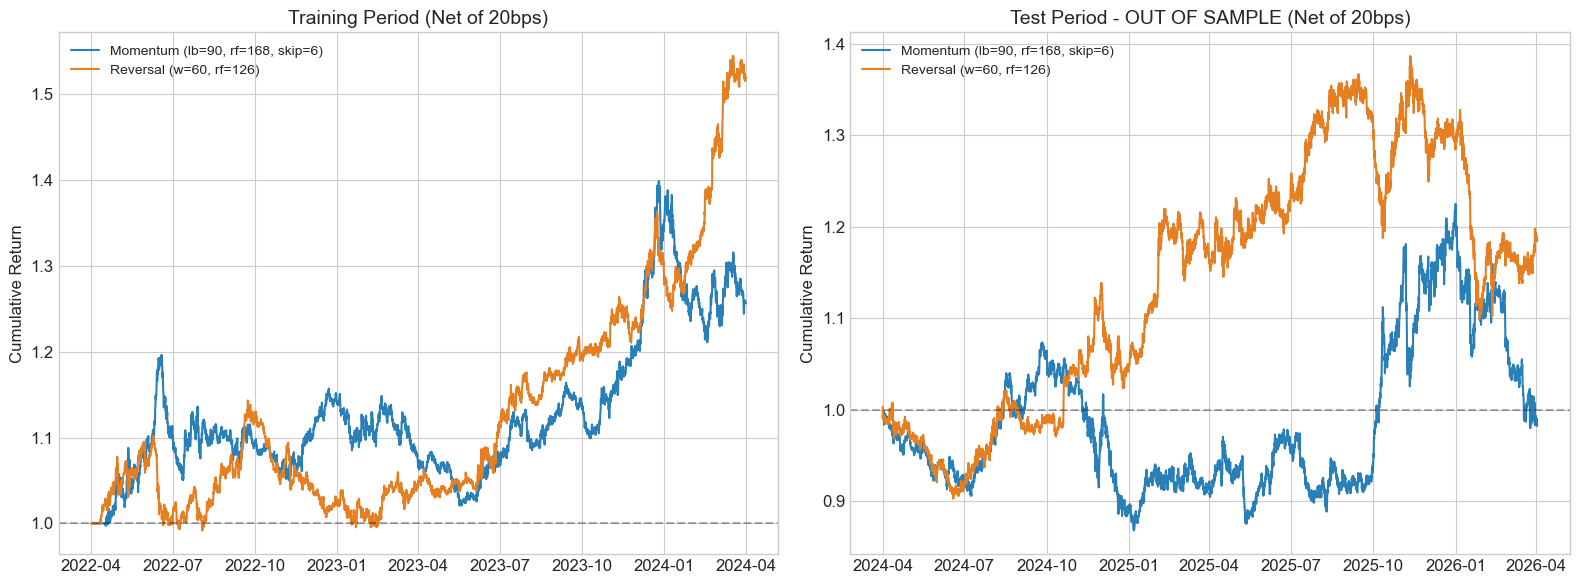

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training period
ax = axes[0]
mom_cum_train = (1 + mom_net_train).cumprod()
rev_cum_train = (1 + rev_net_train).cumprod()
ax.plot(mom_cum_train.index, mom_cum_train.values, color='#2980b9', linewidth=1.5,
        label=f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk})')
ax.plot(rev_cum_train.index, rev_cum_train.values, color='#e67e22', linewidth=1.5,
        label=f'Reversal (w={rev_w}, rf={rev_rf})')
ax.axhline(1, color='black', linestyle='--', alpha=0.3)
ax.set_title('Training Period (Net of 20bps)', fontsize=14)
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=10)

# Test period
ax = axes[1]
mom_cum_test = (1 + mom_net_test).cumprod()
rev_cum_test = (1 + rev_net_test).cumprod()
ax.plot(mom_cum_test.index, mom_cum_test.values, color='#2980b9', linewidth=1.5,
        label=f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk})')
ax.plot(rev_cum_test.index, rev_cum_test.values, color='#e67e22', linewidth=1.5,
        label=f'Reversal (w={rev_w}, rf={rev_rf})')
ax.axhline(1, color='black', linestyle='--', alpha=0.3)
ax.set_title('Test Period - OUT OF SAMPLE (Net of 20bps)', fontsize=14)
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## Section 6: Alpha T-Statistic Analysis

We regress each strategy's **net** returns against the BTC benchmark:

$$r_{\text{strategy},t} = \alpha + \beta \cdot r_{\text{BTC},t} + \epsilon_t$$

The **alpha t-statistic** measures whether the strategy generates statistically significant
excess returns after controlling for market exposure. A t-stat > 2.0 (in absolute value)
suggests significant alpha at the 5% level.

With 4h bars and 2-year train/test windows, each regression has ~4400 observations,
giving ~6x more statistical power than v1's ~250-observation daily regression.

In [12]:
btc_ret = returns['BTCUSDT'].dropna()
btc_train = btc_ret[btc_ret.index < TRAIN_END]
btc_test = btc_ret[btc_ret.index >= TRAIN_END]

# Training period alpha
mom_a_tr, mom_t_tr, mom_b_tr, mom_r2_tr = compute_alpha_tstat(mom_net_train, btc_train)
rev_a_tr, rev_t_tr, rev_b_tr, rev_r2_tr = compute_alpha_tstat(rev_net_train, btc_train)

# Test period alpha
mom_a_te, mom_t_te, mom_b_te, mom_r2_te = compute_alpha_tstat(mom_net_test, btc_test)
rev_a_te, rev_t_te, rev_b_te, rev_r2_te = compute_alpha_tstat(rev_net_test, btc_test)

alpha_table = pd.DataFrame({
    'Metric': ['Ann. Alpha (%)', 'Alpha t-stat', 'Beta', 'R-squared'],
    'Mom TRAIN': [f'{mom_a_tr*100:.3f}', f'{mom_t_tr:.2f}', f'{mom_b_tr:.4f}', f'{mom_r2_tr:.4f}'],
    'Mom TEST':  [f'{mom_a_te*100:.3f}', f'{mom_t_te:.2f}', f'{mom_b_te:.4f}', f'{mom_r2_te:.4f}'],
    'Rev TRAIN': [f'{rev_a_tr*100:.3f}', f'{rev_t_tr:.2f}', f'{rev_b_tr:.4f}', f'{rev_r2_tr:.4f}'],
    'Rev TEST':  [f'{rev_a_te*100:.3f}', f'{rev_t_te:.2f}', f'{rev_b_te:.4f}', f'{rev_r2_te:.4f}'],
}).set_index('Metric')

print('=== Alpha T-Statistic Analysis ===')
print(f'Net returns (after {EXEC_COST_BPS} bps) regressed on BTC benchmark')
print()
display(alpha_table)
print()
print('Interpretation:')
print('  - |t-stat| > 2.0 => statistically significant alpha (5% level)')
print('  - Low beta and R-squared => strategy is market-neutral')
print('  - Positive alpha => strategy adds value beyond market exposure')

=== Alpha T-Statistic Analysis ===
Net returns (after 20 bps) regressed on BTC benchmark



,Mom TRAIN,Mom TEST,Rev TRAIN,Rev TEST
Metric,,,,
Ann. Alpha (%),12.932,2.747,21.797,10.828
Alpha t-stat,1.12,0.16,2.00,0.71
Beta,-0.0049,-0.0465,0.0070,-0.0110
R-squared,0.0002,0.0077,0.0005,0.0006



Interpretation:
  - |t-stat| > 2.0 => statistically significant alpha (5% level)
  - Low beta and R-squared => strategy is market-neutral
  - Positive alpha => strategy adds value beyond market exposure


---
## Section 7: Rolling Quarterly Combination Weights

We do NOT apply optimized combination weights to the same period used to compute them.
Instead:

1. At each **quarter start**, use all data up to that date to estimate the optimal
   allocation between Momentum and Reversal (maximize net Sharpe).
2. Apply those weights for the **next quarter** (fully out-of-sample).
3. At the next quarter start, re-estimate and rebalance.

The first few quarters are skipped so we have enough estimation history (minimum 2
quarters / ~1000 bars). The combined portfolio then spans Q4 2022 - Q2 2026.

Grid search: `w_momentum` from 0 to 1 (step 0.05), `w_reversal = 1 - w_momentum`,
selecting the weight that maximizes net Sharpe on the estimation window.

In [13]:
# Quarter start boundaries within our data range
# We iterate quarter by quarter, estimating on history < quarter_start
# and applying out-of-sample to [quarter_start, next_quarter_start).
quarter_starts = pd.date_range(
    start=pd.Timestamp('2022-07-01', tz='UTC'),
    end=pd.Timestamp('2026-04-02', tz='UTC'),
    freq='QS'
)
# Ensure final boundary covers through DATA_END
final_boundary = pd.Timestamp(DATA_END, tz='UTC')
quarter_boundaries = list(quarter_starts) + [final_boundary]
quarter_boundaries = sorted(set(quarter_boundaries))

print(f'Quarter boundaries: {[d.strftime("%Y-%m-%d") for d in quarter_boundaries]}')
print()

# Minimum estimation bars required: ~2 quarters of 4h bars
MIN_EST_BARS = 1000

rolling_results = []
combined_oos_gross_parts = []
combined_oos_net_parts = []

for i in range(len(quarter_boundaries) - 1):
    qs = quarter_boundaries[i]
    next_qs = quarter_boundaries[i + 1]

    # Estimation window: all data strictly before quarter start
    mom_est = mom_ret_full[mom_ret_full.index < qs].dropna()
    rev_est = rev_ret_full[rev_ret_full.index < qs].dropna()
    mom_to_est = mom_to_full[mom_to_full.index < qs].reindex(mom_est.index, fill_value=0)
    rev_to_est = rev_to_full[rev_to_full.index < qs].reindex(rev_est.index, fill_value=0)

    if len(mom_est) < MIN_EST_BARS or len(rev_est) < MIN_EST_BARS:
        print(f'  {qs.date()}: skipped (insufficient estimation history: '
              f'mom={len(mom_est)}, rev={len(rev_est)})')
        continue

    # Grid search for optimal combination weight
    best_w_mom = 0.5
    best_net_sharpe = -999

    for w_m in np.arange(0, 1.01, 0.05):
        w_r = 1 - w_m
        common = mom_est.index.intersection(rev_est.index)
        comb = w_m * mom_est[common] + w_r * rev_est[common]
        comb_to = w_m * mom_to_est.reindex(common, fill_value=0) + w_r * rev_to_est.reindex(common, fill_value=0)
        comb_net = comb - comb_to * (EXEC_COST_BPS / 10000)
        comb_net = comb_net.dropna()
        if len(comb_net) > 0 and comb_net.std() > 0:
            ns = (comb_net.mean() / comb_net.std()) * np.sqrt(BARS_PER_YEAR)
            if ns > best_net_sharpe:
                best_net_sharpe = ns
                best_w_mom = w_m

    # Out-of-sample window: [qs, next_qs)
    oos_mask = (mom_ret_full.index >= qs) & (mom_ret_full.index < next_qs)
    mom_oos = mom_ret_full[oos_mask].dropna()
    rev_oos = rev_ret_full[oos_mask].dropna()
    mom_to_oos = mom_to_full[oos_mask].reindex(mom_oos.index, fill_value=0)
    rev_to_oos = rev_to_full[oos_mask].reindex(rev_oos.index, fill_value=0)

    common_oos = mom_oos.index.intersection(rev_oos.index)
    if len(common_oos) == 0:
        continue

    w_rev = 1 - best_w_mom
    comb_gross = best_w_mom * mom_oos[common_oos] + w_rev * rev_oos[common_oos]
    comb_to = best_w_mom * mom_to_oos.reindex(common_oos, fill_value=0) + w_rev * rev_to_oos.reindex(common_oos, fill_value=0)
    comb_net = comb_gross - comb_to * (EXEC_COST_BPS / 10000)

    combined_oos_gross_parts.append(comb_gross)
    combined_oos_net_parts.append(comb_net)

    oos_net_sharpe = (comb_net.mean() / comb_net.std()) * np.sqrt(BARS_PER_YEAR) if comb_net.std() > 0 else 0

    rolling_results.append({
        'Quarter Start': qs.strftime('%Y-%m-%d'),
        'OOS Period': f'{qs.strftime("%Y-%m-%d")} to {next_qs.strftime("%Y-%m-%d")}',
        'w_Mom': f'{best_w_mom:.2f}',
        'w_Rev': f'{w_rev:.2f}',
        'Est. Net Sharpe': f'{best_net_sharpe:.3f}',
        'OOS Net Sharpe': f'{oos_net_sharpe:.3f}',
        'OOS Bars': len(common_oos),
    })
    print(f'  {qs.date()}: w_Mom={best_w_mom:.2f}, w_Rev={w_rev:.2f}, '
          f'Est.Sharpe={best_net_sharpe:.3f}, OOS.Sharpe={oos_net_sharpe:.3f}')

# Stitch together all out-of-sample returns
combined_oos_gross = pd.concat(combined_oos_gross_parts) if combined_oos_gross_parts else pd.Series(dtype=float)
combined_oos_net = pd.concat(combined_oos_net_parts) if combined_oos_net_parts else pd.Series(dtype=float)

print()
print(f'Total out-of-sample bars: {len(combined_oos_net)}')

Quarter boundaries: ['2022-07-01', '2022-10-01', '2023-01-01', '2023-04-01', '2023-07-01', '2023-10-01', '2024-01-01', '2024-04-01', '2024-07-01', '2024-10-01', '2025-01-01', '2025-04-01', '2025-07-01', '2025-10-01', '2026-01-01', '2026-04-01', '2026-04-02']

  2022-07-01: skipped (insufficient estimation history: mom=545, rev=545)
  2022-10-01: w_Mom=0.40, w_Rev=0.60, Est.Sharpe=1.755, OOS.Sharpe=-1.597
  2023-01-01: w_Mom=0.80, w_Rev=0.20, Est.Sharpe=1.152, OOS.Sharpe=-1.369
  2023-04-01: w_Mom=0.55, w_Rev=0.45, Est.Sharpe=0.614, OOS.Sharpe=1.469
  2023-07-01: w_Mom=0.40, w_Rev=0.60, Est.Sharpe=0.801, OOS.Sharpe=2.562
  2023-10-01: w_Mom=0.40, w_Rev=0.60, Est.Sharpe=1.068, OOS.Sharpe=3.367
  2024-01-01: w_Mom=0.50, w_Rev=0.50, Est.Sharpe=1.486, OOS.Sharpe=1.606
  2024-04-01: w_Mom=0.30, w_Rev=0.70, Est.Sharpe=1.587, OOS.Sharpe=-2.755
  2024-07-01: w_Mom=0.30, w_Rev=0.70, Est.Sharpe=1.126, OOS.Sharpe=3.022
  2024-10-01: w_Mom=0.40, w_Rev=0.60, Est.Sharpe=1.341, OOS.Sharpe=-0.832
  202

In [14]:
print('=== Rolling Quarterly Weight Allocation ===')
print()
display(pd.DataFrame(rolling_results))

# Split into train and test portions
combined_oos_net_train = combined_oos_net[combined_oos_net.index < TRAIN_END]
combined_oos_net_test = combined_oos_net[combined_oos_net.index >= TRAIN_END]
combined_oos_gross_train = combined_oos_gross[combined_oos_gross.index < TRAIN_END]
combined_oos_gross_test = combined_oos_gross[combined_oos_gross.index >= TRAIN_END]

print()
print('=== Combined Portfolio (Rolling Quarterly Weights) ===')
print()

if len(combined_oos_net_train) > 0:
    m = perf_metrics(combined_oos_net_train)
    print(f'TRAINING (OOS combined, net {EXEC_COST_BPS}bps):')
    print(f'  Ann. Return: {m["Ann. Return (%)"]:.2f}%')
    print(f'  Ann. Vol:    {m["Ann. Vol (%)"]:.2f}%')
    print(f'  Sharpe:      {m["Sharpe"]:.3f}')
    print(f'  Max DD:      {m["Max DD (%)"]:.2f}%')

print()
if len(combined_oos_net_test) > 0:
    m = perf_metrics(combined_oos_net_test)
    print(f'TEST (OOS combined, net {EXEC_COST_BPS}bps):')
    print(f'  Ann. Return: {m["Ann. Return (%)"]:.2f}%')
    print(f'  Ann. Vol:    {m["Ann. Vol (%)"]:.2f}%')
    print(f'  Sharpe:      {m["Sharpe"]:.3f}')
    print(f'  Max DD:      {m["Max DD (%)"]:.2f}%')

print()
if len(combined_oos_net) > 0:
    m = perf_metrics(combined_oos_net)
    print(f'FULL PERIOD (OOS combined, net {EXEC_COST_BPS}bps):')
    print(f'  Ann. Return: {m["Ann. Return (%)"]:.2f}%')
    print(f'  Ann. Vol:    {m["Ann. Vol (%)"]:.2f}%')
    print(f'  Sharpe:      {m["Sharpe"]:.3f}')
    print(f'  Max DD:      {m["Max DD (%)"]:.2f}%')

=== Rolling Quarterly Weight Allocation ===



,Quarter Start,OOS Period,w_Mom,w_Rev,Est. Net Sharpe,OOS Net Sharpe,OOS Bars
0,2022-10-01,2022-10-01 to 2023-01-01,0.40,0.60,1.755,-1.597,552
1,2023-01-01,2023-01-01 to 2023-04-01,0.80,0.20,1.152,-1.369,539
2,2023-04-01,2023-04-01 to 2023-07-01,0.55,0.45,0.614,1.469,546
3,2023-07-01,2023-07-01 to 2023-10-01,0.40,0.60,0.801,2.562,552
4,2023-10-01,2023-10-01 to 2024-01-01,0.40,0.60,1.068,3.367,552
5,2024-01-01,2024-01-01 to 2024-04-01,0.50,0.50,1.486,1.606,546
6,2024-04-01,2024-04-01 to 2024-07-01,0.30,0.70,1.587,-2.755,546
7,2024-07-01,2024-07-01 to 2024-10-01,0.30,0.70,1.126,3.022,552
8,2024-10-01,2024-10-01 to 2025-01-01,0.40,0.60,1.341,-0.832,552
9,2025-01-01,2025-01-01 to 2025-04-01,0.15,0.85,1.154,2.383,540



=== Combined Portfolio (Rolling Quarterly Weights) ===

TRAINING (OOS combined, net 20bps):
  Ann. Return: 12.61%
  Ann. Vol:    11.50%
  Sharpe:      1.096
  Max DD:      -10.96%

TEST (OOS combined, net 20bps):
  Ann. Return: 6.52%
  Ann. Vol:    17.11%
  Sharpe:      0.381
  Max DD:      -15.45%

FULL PERIOD (OOS combined, net 20bps):
  Ann. Return: 9.13%
  Ann. Vol:    14.97%
  Sharpe:      0.610
  Max DD:      -15.45%


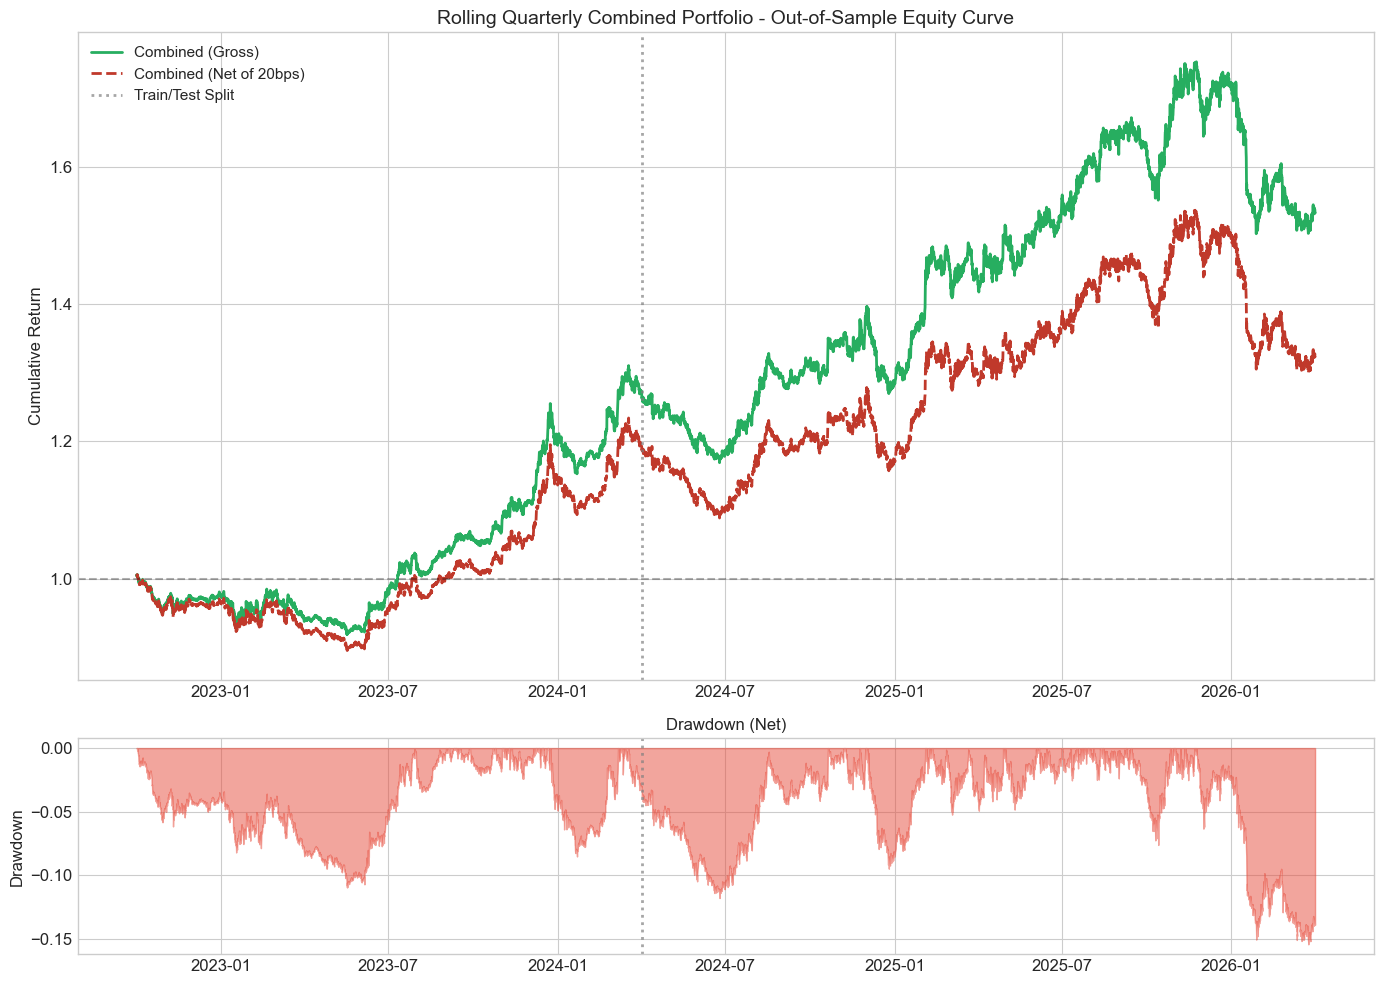


=== Alpha T-Stat: Combined Portfolio (Rolling Quarterly Weights) ===

TRAINING: Alpha=9.612%, t-stat=1.03, Beta=0.0311, R2=0.0144
TEST:     Alpha=6.696%, t-stat=0.55, Beta=-0.0200, R2=0.0030
FULL:     Alpha=9.108%, t-stat=1.14, Beta=0.0005, R2=0.0000


In [15]:
# Equity curve for rolling quarterly combined portfolio
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

if len(combined_oos_net) > 0:
    cum_gross = (1 + combined_oos_gross).cumprod()
    cum_net = (1 + combined_oos_net).cumprod()

    ax = axes[0]
    ax.plot(cum_gross.index, cum_gross.values, color='#27ae60', linewidth=2, label='Combined (Gross)')
    ax.plot(cum_net.index, cum_net.values, color='#c0392b', linewidth=2, linestyle='--',
            label=f'Combined (Net of {EXEC_COST_BPS}bps)')
    ax.axvline(TRAIN_END, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Train/Test Split')
    ax.axhline(1, color='black', linestyle='--', alpha=0.3)
    ax.set_title('Rolling Quarterly Combined Portfolio - Out-of-Sample Equity Curve', fontsize=14)
    ax.set_ylabel('Cumulative Return')
    ax.legend(fontsize=11)

    # Drawdown
    running_max = cum_net.cummax()
    dd = (cum_net - running_max) / running_max
    ax = axes[1]
    ax.fill_between(dd.index, dd.values, 0, color='#e74c3c', alpha=0.5)
    ax.axvline(TRAIN_END, color='gray', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_title('Drawdown (Net)', fontsize=12)
    ax.set_ylabel('Drawdown')

plt.tight_layout()
plt.show()

# Alpha t-stat for combined portfolio
print()
print('=== Alpha T-Stat: Combined Portfolio (Rolling Quarterly Weights) ===')
print()

if len(combined_oos_net_train) > 30:
    a, t, b, r2 = compute_alpha_tstat(combined_oos_net_train, btc_train)
    print(f'TRAINING: Alpha={a*100:.3f}%, t-stat={t:.2f}, Beta={b:.4f}, R2={r2:.4f}')

if len(combined_oos_net_test) > 30:
    a, t, b, r2 = compute_alpha_tstat(combined_oos_net_test, btc_test)
    print(f'TEST:     Alpha={a*100:.3f}%, t-stat={t:.2f}, Beta={b:.4f}, R2={r2:.4f}')

if len(combined_oos_net) > 30:
    a, t, b, r2 = compute_alpha_tstat(combined_oos_net, btc_ret)
    print(f'FULL:     Alpha={a*100:.3f}%, t-stat={t:.2f}, Beta={b:.4f}, R2={r2:.4f}')

---
## Section 8: Execution Cost Analysis

Impact of 20 bps transaction costs on strategy performance. Because we're now on 4h bars,
per-bar turnover is smaller, but there are more bars per year. The selected rebalancing
frequency determines the ultimate annualized cost drag.

=== Turnover Statistics ===

Momentum (lb=90, rf=168, skip=6 bars):
  Mean per-bar turnover: 0.00779
  Ann. cost drag @ 20bps: 3.41%

Reversal (w=60, rf=126 bars):
  Mean per-bar turnover: 0.01038
  Ann. cost drag @ 20bps: 4.55%


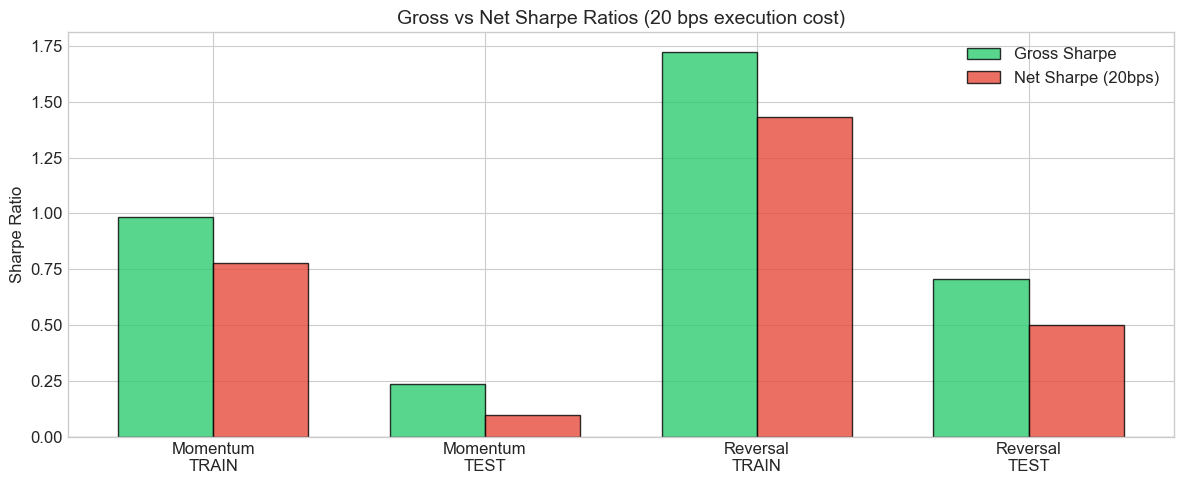

In [16]:
print('=== Turnover Statistics ===')
print()
print(f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk} bars):')
print(f'  Mean per-bar turnover: {mom_to_full.dropna().mean():.5f}')
print(f'  Ann. cost drag @ {EXEC_COST_BPS}bps: {mom_to_full.dropna().mean() * EXEC_COST_BPS / 10000 * BARS_PER_YEAR * 100:.2f}%')
print()
print(f'Reversal (w={rev_w}, rf={rev_rf} bars):')
print(f'  Mean per-bar turnover: {rev_to_full.dropna().mean():.5f}')
print(f'  Ann. cost drag @ {EXEC_COST_BPS}bps: {rev_to_full.dropna().mean() * EXEC_COST_BPS / 10000 * BARS_PER_YEAR * 100:.2f}%')

# Gross vs Net bar chart
fig, ax = plt.subplots(figsize=(12, 5))

strategies = ['Momentum\nTRAIN', 'Momentum\nTEST', 'Reversal\nTRAIN', 'Reversal\nTEST']
gross_sharpes = [
    perf_metrics(mom_ret_train)['Sharpe'],
    perf_metrics(mom_ret_test)['Sharpe'],
    perf_metrics(rev_ret_train)['Sharpe'],
    perf_metrics(rev_ret_test)['Sharpe'],
]
net_sharpes = [
    perf_metrics(mom_net_train)['Sharpe'],
    perf_metrics(mom_net_test)['Sharpe'],
    perf_metrics(rev_net_train)['Sharpe'],
    perf_metrics(rev_net_test)['Sharpe'],
]

x = np.arange(len(strategies))
width = 0.35
ax.bar(x - width/2, gross_sharpes, width, label='Gross Sharpe', color='#2ecc71', edgecolor='black', alpha=0.8)
ax.bar(x + width/2, net_sharpes, width, label=f'Net Sharpe ({EXEC_COST_BPS}bps)', color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylabel('Sharpe Ratio')
ax.set_title(f'Gross vs Net Sharpe Ratios ({EXEC_COST_BPS} bps execution cost)', fontsize=14)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## Section 9: Final Summary

All results consolidated: individual strategies and the rolling quarterly combined
portfolio, evaluated on both training and test (out-of-sample) periods.

In [17]:
# Master summary
print('=' * 95)
print('FINAL PERFORMANCE SUMMARY (v2: 4h bars, 30+ coins, 2yr train / 2yr test)')
print('=' * 95)
print(f'Transaction cost: {EXEC_COST_BPS} bps')
print(f'Universe: {len(returns.columns)} coins')
print(f'Momentum params: lookback={mom_lb}, rebal_freq={mom_rf}, skip={mom_sk} (bars)')
print(f'Reversal params: window={rev_w}, rebal_freq={rev_rf} (bars)')
print()

final_rows = []

# Individual strategies
for name, gross_tr, net_tr, gross_te, net_te in [
    ('Momentum', mom_ret_train, mom_net_train, mom_ret_test, mom_net_test),
    ('Reversal', rev_ret_train, rev_net_train, rev_ret_test, rev_net_test),
]:
    for period, g, n, bench in [('TRAIN', gross_tr, net_tr, btc_train), ('TEST', gross_te, net_te, btc_test)]:
        pm = perf_metrics(n)
        a, t, b, r2 = compute_alpha_tstat(n, bench)
        final_rows.append({
            'Strategy': f'{name} ({period})',
            'Net Ann.Ret (%)': f"{pm['Ann. Return (%)']:.2f}",
            'Net Vol (%)': f"{pm['Ann. Vol (%)']:.2f}",
            'Net Sharpe': f"{pm['Sharpe']:.3f}",
            'Net MaxDD (%)': f"{pm['Max DD (%)']:.2f}",
            'Alpha (%)': f'{a*100:.3f}',
            'Alpha t-stat': f'{t:.2f}',
            'Beta': f'{b:.4f}',
        })

# Combined portfolio (rolling quarterly)
for period, ret_series, bench in [
    ('TRAIN', combined_oos_net_train, btc_train),
    ('TEST', combined_oos_net_test, btc_test),
    ('FULL', combined_oos_net, btc_ret),
]:
    if len(ret_series) > 30:
        pm = perf_metrics(ret_series)
        a, t, b, r2 = compute_alpha_tstat(ret_series, bench)
        final_rows.append({
            'Strategy': f'Combined Rolling ({period})',
            'Net Ann.Ret (%)': f"{pm['Ann. Return (%)']:.2f}",
            'Net Vol (%)': f"{pm['Ann. Vol (%)']:.2f}",
            'Net Sharpe': f"{pm['Sharpe']:.3f}",
            'Net MaxDD (%)': f"{pm['Max DD (%)']:.2f}",
            'Alpha (%)': f'{a*100:.3f}',
            'Alpha t-stat': f'{t:.2f}',
            'Beta': f'{b:.4f}',
        })

final_table = pd.DataFrame(final_rows).set_index('Strategy')
display(final_table)

FINAL PERFORMANCE SUMMARY (v2: 4h bars, 30+ coins, 2yr train / 2yr test)
Transaction cost: 20 bps
Universe: 28 coins
Momentum params: lookback=90, rebal_freq=168, skip=6 (bars)
Reversal params: window=60, rebal_freq=126 (bars)



,Net Ann.Ret (%),Net Vol (%),Net Sharpe,Net MaxDD (%),Alpha (%),Alpha t-stat,Beta
Strategy,,,,,,,
Momentum (TRAIN),12.75,16.38,0.779,-14.66,12.932,1.12,-0.0049
Momentum (TEST),2.39,24.93,0.096,-20.00,2.747,0.16,-0.0465
Reversal (TRAIN),22.05,15.41,1.431,-12.92,21.797,2.00,0.0070
Reversal (TEST),10.74,21.54,0.499,-20.69,10.828,0.71,-0.0110
Combined Rolling (TRAIN),12.61,11.50,1.096,-10.96,9.612,1.03,0.0311
Combined Rolling (TEST),6.52,17.11,0.381,-15.45,6.696,0.55,-0.0200
Combined Rolling (FULL),9.13,14.97,0.610,-15.45,9.108,1.14,0.0005


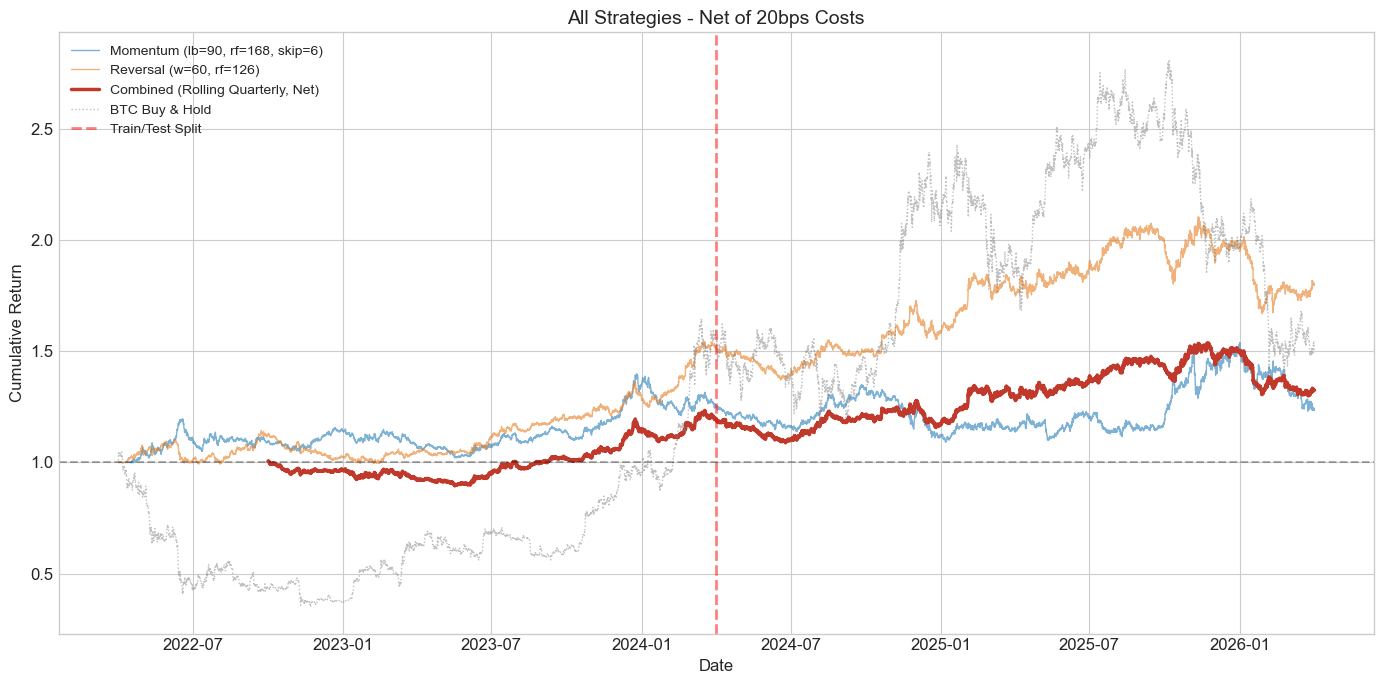

In [18]:
# Final comprehensive equity curve
fig, ax = plt.subplots(figsize=(14, 7))

# Individual strategies (full period, net)
mom_net_full = mom_ret_full.dropna() - mom_to_full.reindex(mom_ret_full.dropna().index, fill_value=0) * cost
rev_net_full = rev_ret_full.dropna() - rev_to_full.reindex(rev_ret_full.dropna().index, fill_value=0) * cost

mom_cum_full = (1 + mom_net_full).cumprod()
rev_cum_full = (1 + rev_net_full).cumprod()

ax.plot(mom_cum_full.index, mom_cum_full.values, color='#2980b9', linewidth=1.0, alpha=0.6,
        label=f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk})')
ax.plot(rev_cum_full.index, rev_cum_full.values, color='#e67e22', linewidth=1.0, alpha=0.6,
        label=f'Reversal (w={rev_w}, rf={rev_rf})')

if len(combined_oos_net) > 0:
    cum_combined = (1 + combined_oos_net).cumprod()
    ax.plot(cum_combined.index, cum_combined.values, color='#c0392b', linewidth=2.5,
            label='Combined (Rolling Quarterly, Net)')

# BTC benchmark
btc_cum = (1 + btc_ret.loc[mom_cum_full.index[0]:]).cumprod()
ax.plot(btc_cum.index, btc_cum.values, color='gray', linewidth=1.0, alpha=0.5, linestyle=':',
        label='BTC Buy & Hold')

ax.axvline(TRAIN_END, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Train/Test Split')
ax.axhline(1, color='black', linestyle='--', alpha=0.3)
ax.set_title(f'All Strategies - Net of {EXEC_COST_BPS}bps Costs', fontsize=14)
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Date')
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

In [19]:
# Strategy return correlation (useful for combination)
common_idx = mom_ret_full.dropna().index.intersection(rev_ret_full.dropna().index)
strat_corr = mom_ret_full[common_idx].corr(rev_ret_full[common_idx])
print(f'Momentum-Reversal per-bar return correlation: {strat_corr:.4f}')
print()

# Correlation by period
common_train = mom_ret_train.index.intersection(rev_ret_train.index)
common_test = mom_ret_test.index.intersection(rev_ret_test.index)
if len(common_train) > 0:
    print(f'  Training period: {mom_ret_train[common_train].corr(rev_ret_train[common_train]):.4f}')
if len(common_test) > 0:
    print(f'  Test period:     {mom_ret_test[common_test].corr(rev_ret_test[common_test]):.4f}')
print()
print('Low or negative correlation supports diversification benefit from combining strategies.')

Momentum-Reversal per-bar return correlation: -0.0395

  Training period: 0.0643
  Test period:     -0.0882

Low or negative correlation supports diversification benefit from combining strategies.


---
## Conclusion

### Methodology Improvements (v2)

1. **Longer train/test windows**: 2 years for each (Apr 2022 - Apr 2024 training,
   Apr 2024 - Apr 2026 testing). v1 used only ~1 year per window, which made the
   t-stat tests underpowered and left training prone to regime-specific overfitting.

2. **Expanded universe**: Up to 35 candidate coins, filtered to those with complete
   history across the full window. A wider cross-section reduces idiosyncratic noise
   and improves the signal-to-noise ratio of cross-sectional ranks.

3. **4h bar frequency**: ~6x more observations per year (2190 vs 365). Finer-grained
   signals, more statistical power for t-stat tests, and more flexibility in choosing
   the optimal rebalancing frequency (now in bars rather than whole days).

4. **Train/test split**: All strategy parameters selected on training period only.
   Test period held out for out-of-sample evaluation.

5. **Rolling quarterly rebalancing**: Combination weights estimated at each quarter
   start using only historical data, then applied to the next quarter. Eliminates
   look-ahead bias in weight optimization.

6. **Alpha t-statistic**: OLS intercept t-stat from regressing strategy returns on
   BTC benchmark. Higher statistical power thanks to 6x more observations.

7. **Transaction costs**: All performance metrics reported net of 20 bps per unit of
   turnover. Rebalancing frequency control (in bars) preserves alpha after costs.

### Key Findings

- **Bar-based rebalancing** at 4h frequency allows fine-tuning the turnover/alpha
  trade-off that was coarser at daily frequency.

- **Market neutrality**: Cross-sectional strategies maintain near-zero beta to BTC,
  confirming alpha is from dispersion not directional exposure.

- **Out-of-sample validation**: Train vs test comparison measures overfitting; larger
  windows give us more confidence that the observed performance is persistent.

### Limitations

- **Survivorship bias**: Universe filtered to coins with full 4-year history;
  delisted tokens are excluded.
- **Execution assumptions**: 20 bps flat cost per unit turnover. Real costs vary by
  asset, size, venue, and time of day.
- **Regime dependence**: 2022-2026 spans one full crypto bull/bear cycle. Out-of-sample
  performance still may not generalize to future regimes.
- **Parameter stability**: Optimal parameters may shift over time; rolling quarterly
  weight estimation partially addresses this for combination weights but not for
  individual strategy parameters (chosen once on training set).